# Adjusted or Not — a quantitative teardown \U0001F52C
### Implied yields · Spearman and pair flips · selection isolated from income · an equal-total-return control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The design
decision that makes this study more than an arithmetic reminder: both arms of the backtest are
**scored on total returns**, so the difference between them is not the dividend income — it is
the assets the signal chose.

> ⚠️ **Not investment advice.** Both conventions from Yahoo! Finance in one pass, pinned as-of
> the date in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from adj_mode import data, strategy as st

panels = data.load_pair()
tr, px = panels["tr"], panels["pxonly"]
print(f"as-of {data.AS_OF} | {len(tr):,} sessions "
      f"{tr.index[0].date()} -> {tr.index[-1].date()}")
yt = st.yield_table(tr, px).sort_values("implied_yield")
print(yt[["cagr_tr", "cagr_px", "implied_yield", "share_of_return"]].round(4).to_string())

as-of 2026-06-30 | 7,166 sessions 1998-01-02 -> 2026-06-30


        cagr_tr  cagr_px  implied_yield  share_of_return
ticker                                                  
QQQ      0.1096   0.1027         0.0069           0.0633
IWM      0.0889   0.0748         0.0140           0.1579
SPY      0.0927   0.0741         0.0187           0.2014
EFA      0.0648   0.0363         0.0285           0.4394
VYM      0.0929   0.0599         0.0329           0.3548
TLT      0.0373   0.0024         0.0349           0.9345
XLU      0.0776   0.0412         0.0364           0.4688
HYG      0.0493  -0.0137         0.0631           1.2787


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | The gap between the two conventions is the reinvested dividend, and on this universe it runs from **0.69%/yr** (QQQ) to **6.31%/yr** (HYG) — which on HYG is **128% of its entire total return**. Volatility is almost untouched (largest difference 0.14%), so every risk-adjusted ratio moves with the numerator alone: the Sharpe gap reaches **0.57**. |
| **Usefulness** | Useful | Yes. Ranking the same universe on price charts instead of total returns reorders **4%** of asset pairs in an average month and picks a different leader in **6%** of them. Run as a momentum sleeve — both arms scored on total returns, so only the *selection* differs — ranking on price gives +7.26%/yr against +6.41%/yr for ranking on total return (-0.85%/yr, Sharpe +0.51 vs +0.47), and it holds a portfolio yielding -0.16% less. The price-only signal is not neutral — it is a systematic bet against income. |

> \U0001F4A1 **In plain words.** The convention subtracts a constant from every return, and a
> constant subtraction is exactly the kind of thing a cross-sectional sort is most sensitive
> to.

## 1 · The claim, stated precisely

- **H₁.** CAGR(total return) − CAGR(price) = the reinvested dividend yield, exactly.
- **H₂.** Volatility is (nearly) unchanged, so the entire Sharpe difference comes from the
  numerator.
- **H₃.** A cross-sectional ranking on price returns is a **yield-tilted** ranking, and the
  tilt is proportional to yield dispersion.
- **H₄.** A momentum sleeve that ranks on price, but is scored on total return, underperforms
  one that ranks on total return — because it selects worse, not because it earns less income.

## 2 · The protocol

Both panels come from one provider in one pass, on a **common index**. The backtest scores both
arms on the total-return panel, which is what isolates H₄ from the trivial income effect. The
synthetic control fixes every asset's total return to be identical and varies only the yield,
so any ranking difference there is attributable to the convention alone.

## 3 · The teardown

### 3.1 The decomposition, and the volatility check

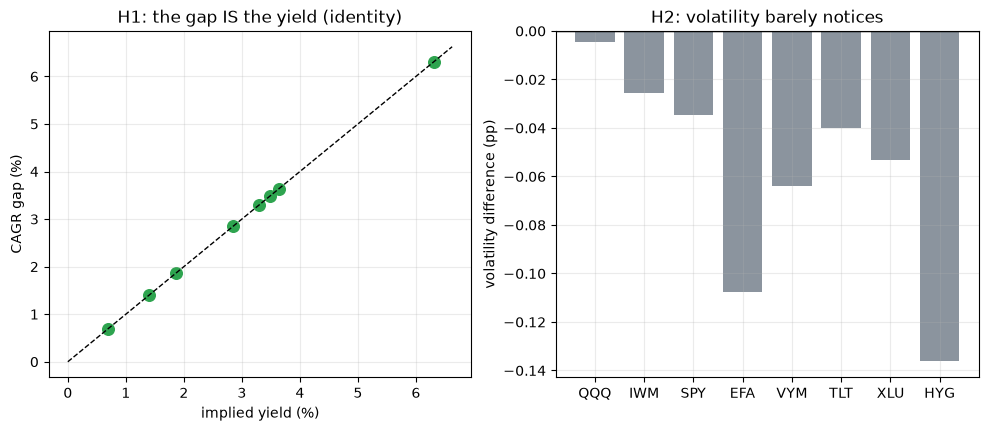

,n,cagr_tr,cagr_px,implied_yield,vol_tr,vol_px,share_of_return
ticker,,,,,,,
QQQ,6869,0.1096,0.1027,0.0069,0.2695,0.2695,0.0633
IWM,6561,0.0889,0.0748,0.0140,0.2390,0.2393,0.1579
SPY,7166,0.0927,0.0741,0.0187,0.1938,0.1941,0.2014
EFA,6246,0.0648,0.0363,0.0285,0.2080,0.2091,0.4394
VYM,4933,0.0929,0.0599,0.0329,0.1813,0.1819,0.3548
TLT,6018,0.0373,0.0024,0.0349,0.1430,0.1434,0.9345
XLU,6921,0.0776,0.0412,0.0364,0.1925,0.1931,0.4688
HYG,4836,0.0493,-0.0137,0.0631,0.1089,0.1103,1.2787


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(yt["implied_yield"] * 100, (yt["cagr_tr"] - yt["cagr_px"]) * 100, s=70,
                color="#2ea44f")
lim = [0, yt["implied_yield"].max() * 105]
axes[0].plot(lim, lim, ls="--", color="k", lw=1)
axes[0].set_xlabel("implied yield (%)"); axes[0].set_ylabel("CAGR gap (%)")
axes[0].set_title("H1: the gap IS the yield (identity)")
axes[1].bar(yt.index, (yt["vol_tr"] - yt["vol_px"]) * 100, color="#8b949e")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_ylabel("volatility difference (pp)")
axes[1].set_title("H2: volatility barely notices")
plt.show()
yt.round(4)

### 3.2 Where the Sharpe goes

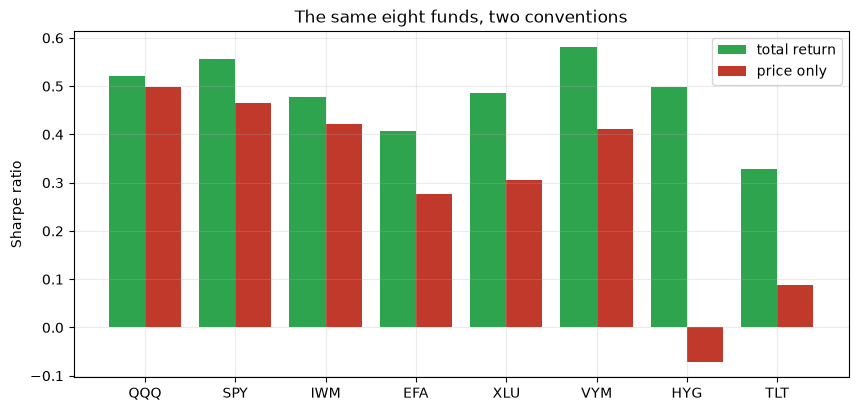

,sharpe_tr,maxdd_tr,years_underwater_tr,sharpe_px,maxdd_px,years_underwater_px,sharpe_gap,maxdd_gap
ticker,,,,,,,,
QQQ,0.5210,-0.8300,25.3970,0.4980,-0.8300,25.5360,0.0230,-0.0000
SPY,0.5560,-0.5520,25.6750,0.4660,-0.5650,26.2420,0.0900,0.0130
IWM,0.4770,-0.5860,24.4840,0.4220,-0.5950,24.7100,0.0550,0.0090
EFA,0.4070,-0.6100,23.3770,0.2760,-0.6320,24.0200,0.1310,0.0210
XLU,0.4850,-0.5230,25.8570,0.3060,-0.5570,26.6270,0.1790,0.0340
VYM,0.5820,-0.5700,17.4960,0.4120,-0.5880,18.2060,0.1700,0.0180
HYG,0.4970,-0.3420,16.7700,-0.0710,-0.4190,19.1270,0.5680,0.0770
TLT,0.3280,-0.4840,23.1550,0.0890,-0.5180,23.5400,0.2400,0.0340


In [4]:
rt = st.risk_table(tr, px)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(rt))
ax.bar(x - 0.2, rt["sharpe_tr"], width=0.4, color="#2ea44f", label="total return")
ax.bar(x + 0.2, rt["sharpe_px"], width=0.4, color="#c0392b", label="price only")
ax.set_xticks(x); ax.set_xticklabels(rt.index)
ax.set_ylabel("Sharpe ratio"); ax.legend()
ax.set_title("The same eight funds, two conventions")
plt.show()
rt.round(3)

### 3.3 The cross-sectional damage, month by month

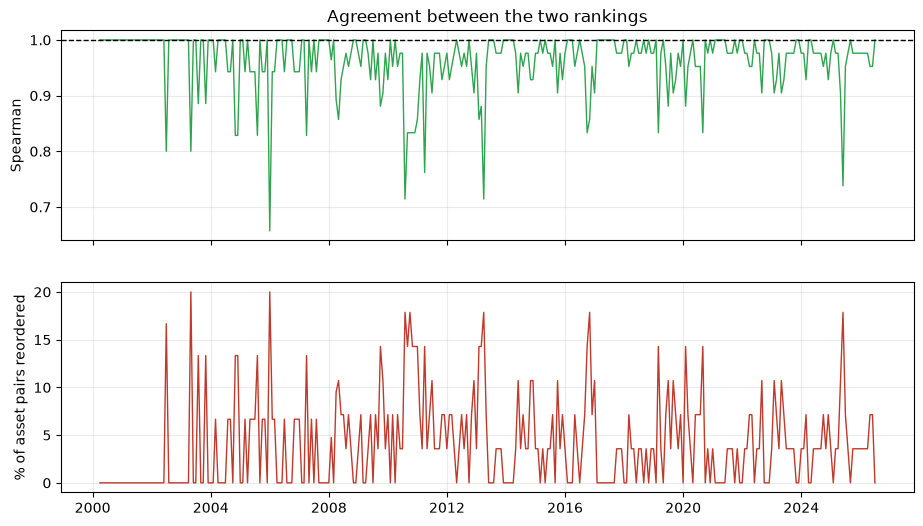

       spearman  flip_share
count  316.0000    316.0000
mean     0.9630      0.0410
std      0.0530      0.0460
min      0.6570      0.0000
25%      0.9520      0.0000
50%      0.9760      0.0360
75%      1.0000      0.0710
max      1.0000      0.2000


In [5]:
rank = st.ranking_table(tr, px)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(rank.index, rank["spearman"], lw=1, color="#2ea44f")
axes[0].axhline(1.0, color="k", lw=1, ls="--")
axes[0].set_ylabel("Spearman"); axes[0].set_title("Agreement between the two rankings")
axes[1].plot(rank.index, rank["flip_share"] * 100, lw=1, color="#c0392b")
axes[1].set_ylabel("% of asset pairs reordered")
plt.show()
print(rank[["spearman", "flip_share", "same_top", "same_bottom"]].describe().round(3).to_string())

> \U0001F4A1 **In plain words.** A rank correlation of 0.95 sounds like agreement. It means
> that in a typical month a few pairs of assets swap places — and a top-3 sleeve holds only
> three of them, so a few swaps is the whole portfolio.

### 3.4 The sleeve, and the tilt it acquires

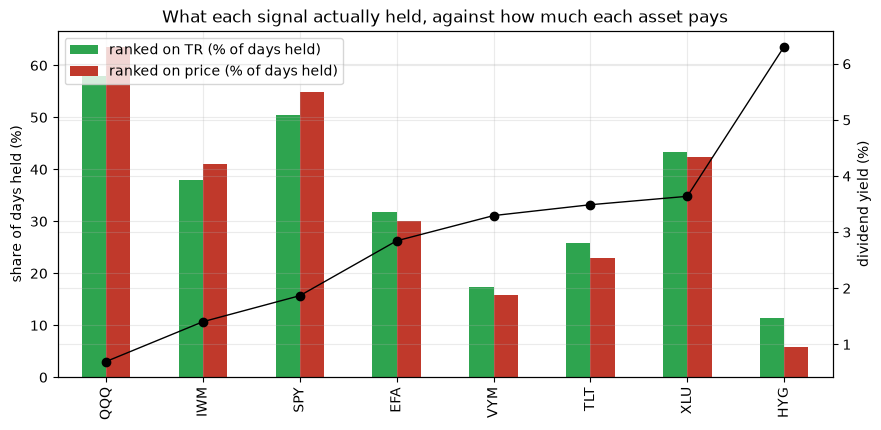

average held yield: TR-ranked 2.37%, price-ranked 2.22%


In [6]:
on_tr = st.momentum_backtest(tr, tr, top_k=3, cost_bps=5.0)
on_px = st.momentum_backtest(px, tr, top_k=3, cost_bps=5.0)
ys = yt["implied_yield"]
hold_tr = (on_tr["weights"] > 0).mean() * 100
hold_px = (on_px["weights"] > 0).mean() * 100
d = pd.DataFrame({"ranked on TR (% of days held)": hold_tr,
                  "ranked on price (% of days held)": hold_px,
                  "yield (%)": ys * 100}).sort_values("yield (%)")
fig, ax = plt.subplots(figsize=(10, 4.5))
d[["ranked on TR (% of days held)", "ranked on price (% of days held)"]].plot.bar(
    ax=ax, color=["#2ea44f", "#c0392b"])
ax2 = ax.twinx()
ax2.plot(range(len(d)), d["yield (%)"], color="k", marker="o", lw=1, label="yield")
ax2.set_ylabel("dividend yield (%)")
ax.set_ylabel("share of days held (%)"); ax.legend(title="", loc="upper left")
ax.set_title("What each signal actually held, against how much each asset pays")
plt.show()
print(f"average held yield: TR-ranked {st.holding_yield(on_tr['weights'], ys):.2%}, "
      f"price-ranked {st.holding_yield(on_px['weights'], ys):.2%}")

### 3.5 Does the conclusion survive the parameters?

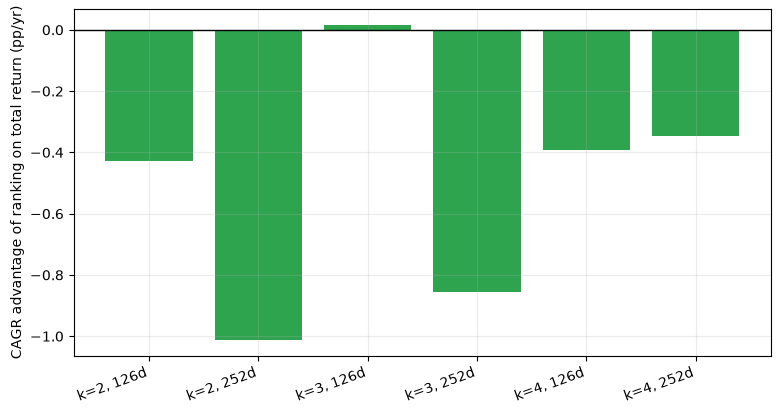

,top_k,lookback,cagr gap,sharpe gap
0,2,126,-0.0043,-0.0186
1,2,252,-0.0101,-0.0632
2,3,126,0.0002,0.0054
3,3,252,-0.0085,-0.0445
4,4,126,-0.0039,-0.0187
5,4,252,-0.0035,-0.0155


In [7]:
rows = []
for k in (2, 3, 4):
    for lb in (126, 252):
        a = st.momentum_backtest(tr, tr, top_k=k, lookback=lb, cost_bps=5.0)
        b = st.momentum_backtest(px, tr, top_k=k, lookback=lb, cost_bps=5.0)
        rows.append({"top_k": k, "lookback": lb, "cagr gap": a["cagr"] - b["cagr"],
                     "sharpe gap": a["sharpe"] - b["sharpe"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([f"k={r.top_k}, {r.lookback}d" for r in d.itertuples()], d["cagr gap"] * 100,
       color="#2ea44f")
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("CAGR advantage of ranking on total return (pp/yr)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.show()
d.round(4)

### 3.6 The control: equal total returns, different yields

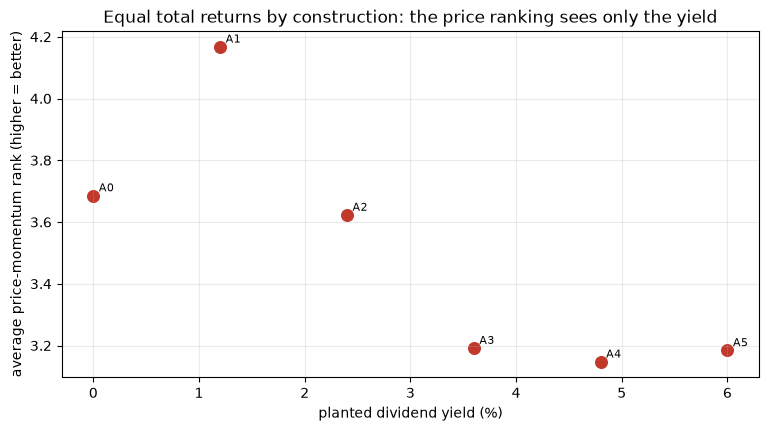

correlation between planted yield and average price rank: -0.795


In [8]:
a, b, truth = data.synthetic_pair(n_years=20, signal_strength=1.0, seed=972)
sig_px = st.trailing_return(b).dropna()
mean_rank = sig_px.rank(axis=1).mean()
ys_true = pd.Series(truth["yields"], index=a.columns)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(ys_true * 100, mean_rank, s=70, color="#c0392b")
for c in a.columns:
    ax.annotate(c, (ys_true[c] * 100, mean_rank[c]), fontsize=8, xytext=(4, 3),
                textcoords="offset points")
ax.set_xlabel("planted dividend yield (%)")
ax.set_ylabel("average price-momentum rank (higher = better)")
ax.set_title("Equal total returns by construction: the price ranking sees only the yield")
plt.show()
n0, _, _ = data.synthetic_pair(n_years=20, signal_strength=0.0, seed=972)[0], None, None
print(f"correlation between planted yield and average price rank: "
      f"{mean_rank.corr(ys_true):+.3f}")

## 4 · The verdict

In [9]:
summary = pd.DataFrame({
    "largest implied yield": [yt["implied_yield"].max()],
    "on": [yt["implied_yield"].idxmax()],
    "largest Sharpe gap": [rt["sharpe_gap"].max()],
    "mean pair flips": [rank["flip_share"].mean()],
    "momentum CAGR gap": [on_tr["cagr"] - on_px["cagr"]],
    "yield tilt": [st.holding_yield(on_px["weights"], ys) -
                   st.holding_yield(on_tr["weights"], ys)],
}).T.rename(columns={0: "value"})
summary

,value
largest implied yield,0.0631
on,HYG
largest Sharpe gap,0.5681
mean pair flips,0.0407
momentum CAGR gap,-0.0085
yield tilt,-0.0016


## 5 · Going further

- **A stock cross-section** with 500 names and yields from 0% to 10% turns the ranking damage
  from a nuisance into a factor exposure.
- **After-tax series**: the honest convention for a taxable holder is a third series, between
  the two here.
- **Shareholder yield** (dividends + buybacks) is the economically complete version, and
  buybacks appear in the price series — the mirror image of this problem.